# 01 - Análisis Exploratorio de Datos Gold

## Proyecto: Predicción de demanda para retail de agua

Este notebook realiza el Análisis Exploratorio de Datos sobre la tabla `gold.ml_dataset`, que consolida información de ventas, productos, inventario, marketing, clima y calendario.

El objetivo del EDA es validar la calidad del dataset antes del entrenamiento del modelo predictivo, identificando valores nulos, patrones de demanda, relación con variables externas y posibles casos de demanda censurada por quiebre de stock.

In [19]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text

# Permite importar utils desde src/
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = ROOT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from utils.db import get_engine

engine = get_engine()

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

print("Conexión cargada correctamente.")

Conexión cargada correctamente.


In [20]:
import sys
print(sys.executable)

d:\ICONTINENTAL\PROYECTO-PRODUCTIVO-II-B-IDL02\IDL03_PPIIB-RETAIL-AGUA\.venv\Scripts\python.exe


In [21]:
query = """
SELECT *
FROM gold.ml_dataset
ORDER BY fecha, id_sku;
"""

df = pd.read_sql(query, engine)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Filas: 1098
Columnas: 39


,fecha,id_sku,categoria,volumen_litros,formato_envase,cantidad_vendida_total,stock_apertura,ingresos_almacen,stock_disponible_cierre,stock_minimo,precio_unitario_promedio,descuento_total,porcentaje_descuento_promedio,inversion_ads_total,clics_total,impresiones_total,conversiones_total,temperatura_promedio_celsius,temperatura_maxima_celsius,humedad_porcentaje,precipitacion_mm,alerta_ola_calor,numero_dia_semana,mes,trimestre,es_fin_de_semana,es_feriado,es_quincena,es_fin_mes,temporada,ventas_lag1,ventas_lag7,ventas_roll7,ads_lag1,ads_lag3,riesgo_demanda_censurada,fecha_creacion,fecha_modificacion,usuario_modificacion
0,2024-01-01,SKU_1L,Personal,1.0,Botella,153,540,0,411,180,2.0,0.0,0.0,0.0,0,0,0,20.9,25.2,76.4,0.0,False,1,1,1,False,True,False,False,Verano,0,0,153.0,0.0,0.0,False,2026-05-31 02:43:34.222205,2026-05-31 02:43:34.222205,postgres
1,2024-01-01,SKU_20L,Familiar,20.0,Bidón,64,360,0,296,120,7.5,0.0,0.0,0.0,0,0,0,20.9,25.2,76.4,0.0,False,1,1,1,False,True,False,False,Verano,0,0,64.0,0.0,0.0,False,2026-05-31 02:43:34.222205,2026-05-31 02:43:34.222205,postgres
2,2024-01-01,SKU_500ML,Personal,0.5,Botella,131,720,0,589,240,1.2,0.0,0.0,0.0,0,0,0,20.9,25.2,76.4,0.0,False,1,1,1,False,True,False,False,Verano,0,0,131.0,0.0,0.0,False,2026-05-31 02:43:34.222205,2026-05-31 02:43:34.222205,postgres
3,2024-01-02,SKU_1L,Personal,1.0,Botella,51,411,0,339,180,2.0,0.0,0.0,0.0,0,0,0,20.8,25.1,81.1,0.0,False,2,1,1,False,False,False,False,Verano,153,0,102.0,0.0,0.0,False,2026-05-31 02:43:34.222205,2026-05-31 02:43:34.222205,postgres
4,2024-01-02,SKU_20L,Familiar,20.0,Bidón,88,296,0,208,120,7.5,0.0,0.0,0.0,0,0,0,20.8,25.1,81.1,0.0,False,2,1,1,False,False,False,False,Verano,64,0,76.0,0.0,0.0,False,2026-05-31 02:43:34.222205,2026-05-31 02:43:34.222205,postgres


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1098 entries, 0 to 1097
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   fecha                          1098 non-null   object        
 1   id_sku                         1098 non-null   str           
 2   categoria                      1098 non-null   str           
 3   volumen_litros                 1098 non-null   float64       
 4   formato_envase                 1098 non-null   str           
 5   cantidad_vendida_total         1098 non-null   int64         
 6   stock_apertura                 1098 non-null   int64         
 7   ingresos_almacen               1098 non-null   int64         
 8   stock_disponible_cierre        1098 non-null   int64         
 9   stock_minimo                   1098 non-null   int64         
 10  precio_unitario_promedio       1098 non-null   float64       
 11  descuento_total             

## Revisión inicial de estructura

El dataset `gold.ml_dataset` contiene una fila por combinación de fecha y SKU. Esta granularidad es adecuada para un modelo de predicción de demanda diaria por producto.

La variable objetivo del modelo es `cantidad_vendida_total`.

In [23]:
target = "cantidad_vendida_total"

resumen_target = pd.DataFrame({
    "total_filas": [len(df)],
    "nulos_target": [df[target].isna().sum()],
    "minimo": [df[target].min()],
    "maximo": [df[target].max()],
    "promedio": [df[target].mean()],
    "mediana": [df[target].median()],
    "desviacion": [df[target].std()]
})

resumen_target

,total_filas,nulos_target,minimo,maximo,promedio,mediana,desviacion
0,1098,0,23,321,127.34153,115.0,56.638428


## Validación de la variable objetivo

La variable `cantidad_vendida_total` representa la demanda histórica real observada. Para entrenar el modelo, esta variable no debe tener valores nulos. Además, se revisa su rango mínimo, máximo, promedio y desviación para identificar posibles valores extremos.

In [24]:
columnas_clave = [
    "cantidad_vendida_total",
    "stock_apertura",
    "precio_unitario_promedio",
    "inversion_ads_total",
    "temperatura_promedio_celsius",
    "temperatura_maxima_celsius",
    "ventas_lag1",
    "ventas_lag7",
    "ventas_roll7"
]

nulos = (
    df[columnas_clave]
    .isna()
    .sum()
    .reset_index()
)

nulos.columns = ["columna", "cantidad_nulos"]
nulos["porcentaje_nulos"] = (nulos["cantidad_nulos"] / len(df) * 100).round(2)

nulos

,columna,cantidad_nulos,porcentaje_nulos
0,cantidad_vendida_total,0,0.0
1,stock_apertura,0,0.0
2,precio_unitario_promedio,0,0.0
3,inversion_ads_total,0,0.0
4,temperatura_promedio_celsius,0,0.0
5,temperatura_maxima_celsius,0,0.0
6,ventas_lag1,0,0.0
7,ventas_lag7,0,0.0
8,ventas_roll7,0,0.0


## Revisión de valores nulos

Se revisan los nulos en las principales variables del modelo. La variable objetivo no debe tener nulos. En caso existan nulos en variables explicativas, estos pueden tratarse mediante imputación dentro del pipeline de entrenamiento.

In [25]:
demanda_sku = (
    df.groupby(["id_sku", "categoria", "formato_envase"], as_index=False)
    .agg(
        unidades_vendidas=("cantidad_vendida_total", "sum"),
        promedio_diario=("cantidad_vendida_total", "mean"),
        maximo_diario=("cantidad_vendida_total", "max")
    )
    .sort_values("unidades_vendidas", ascending=False)
)

demanda_sku

,id_sku,categoria,formato_envase,unidades_vendidas,promedio_diario,maximo_diario
2,SKU_500ML,Personal,Botella,61735,168.674863,321
0,SKU_1L,Personal,Botella,47990,131.120219,239
1,SKU_20L,Familiar,Bidón,30096,82.229508,156


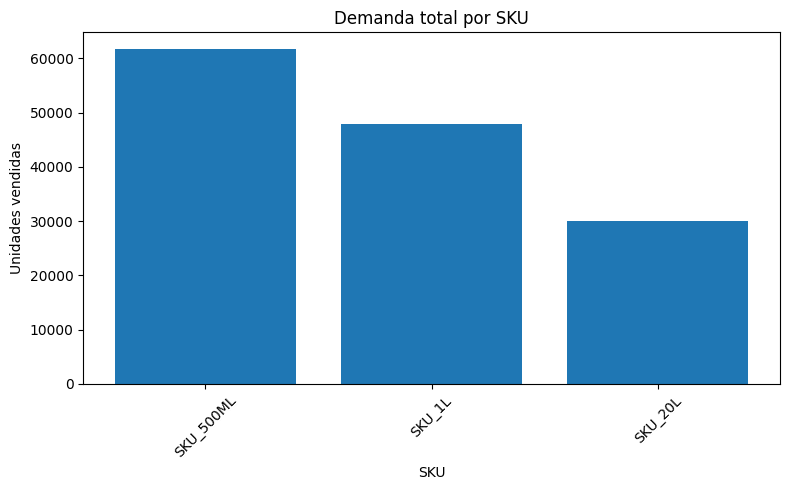

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(demanda_sku["id_sku"], demanda_sku["unidades_vendidas"])
plt.title("Demanda total por SKU")
plt.xlabel("SKU")
plt.ylabel("Unidades vendidas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Demanda por producto

Este análisis permite identificar qué productos concentran mayor volumen de ventas. Esto es relevante porque los errores de predicción en productos de alta rotación tienen mayor impacto en inventarios, quiebres de stock y nivel de servicio.

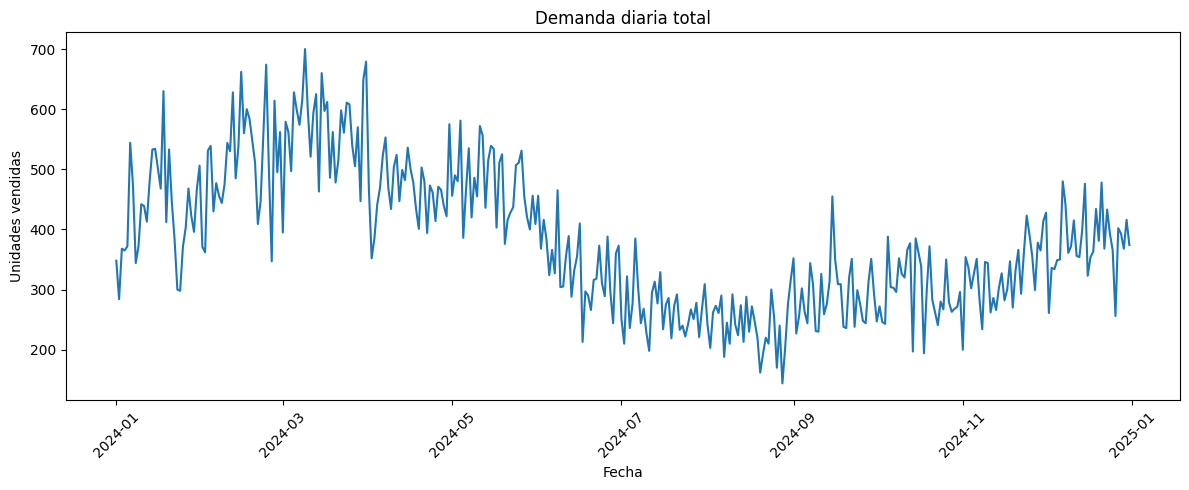

In [27]:
demanda_diaria = (
    df.groupby("fecha", as_index=False)
    .agg(cantidad_vendida_total=("cantidad_vendida_total", "sum"))
)

plt.figure(figsize=(12, 5))
plt.plot(demanda_diaria["fecha"], demanda_diaria["cantidad_vendida_total"])
plt.title("Demanda diaria total")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Comportamiento temporal de la demanda

Se analiza la evolución diaria de la demanda total. Este gráfico permite observar picos de venta, caídas, estacionalidad y cambios de comportamiento a lo largo del tiempo.

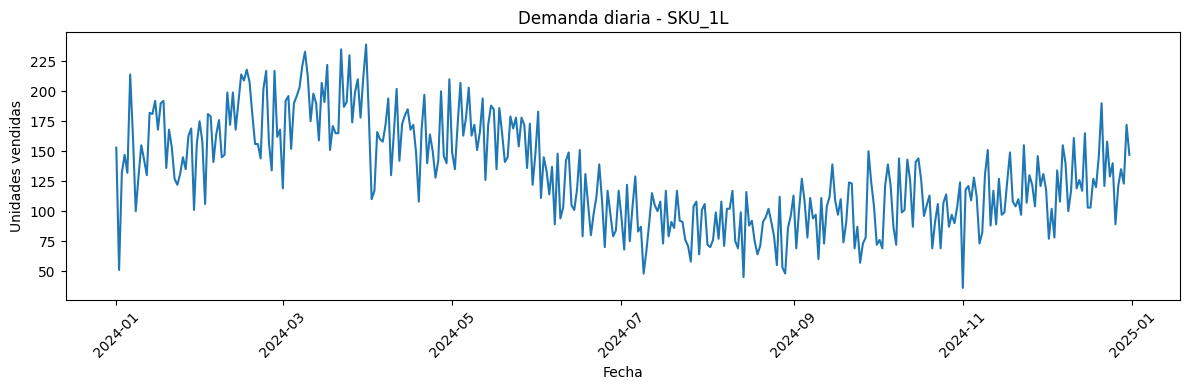

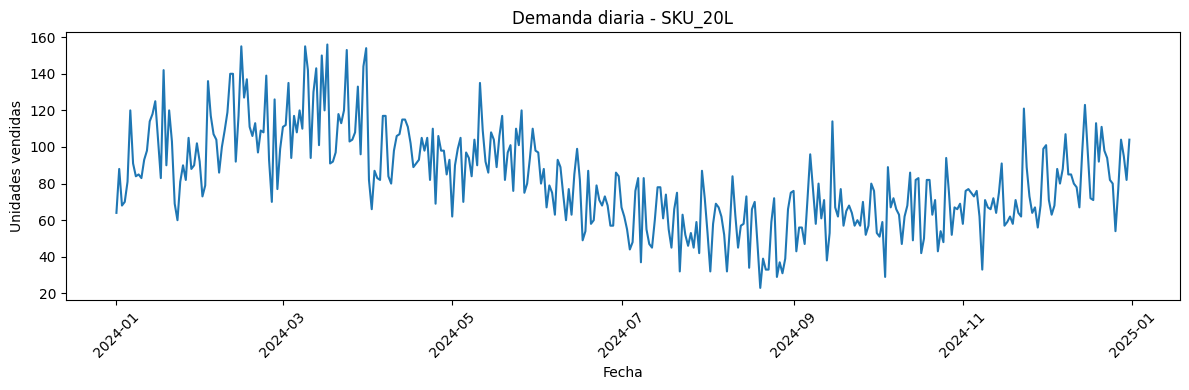

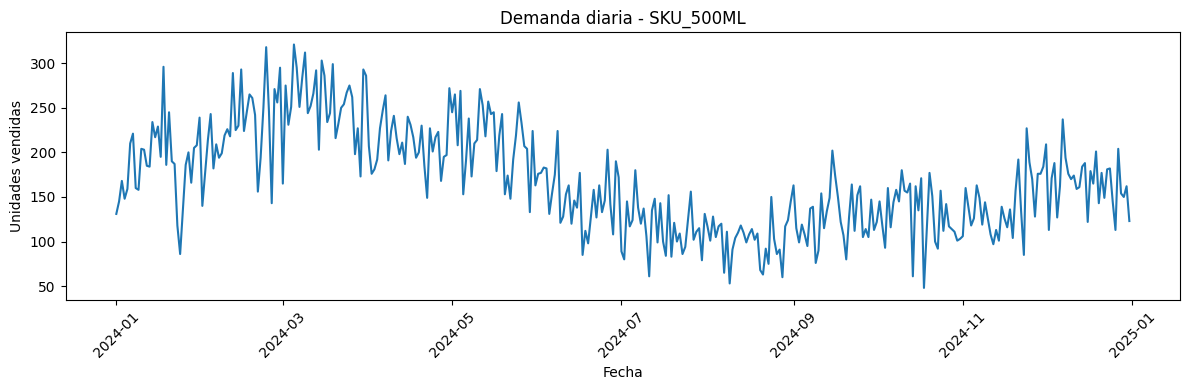

In [28]:
for sku in df["id_sku"].unique():
    temp = df[df["id_sku"] == sku].copy()
    
    plt.figure(figsize=(12, 4))
    plt.plot(temp["fecha"], temp["cantidad_vendida_total"])
    plt.title(f"Demanda diaria - {sku}")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Comportamiento temporal por SKU

La demanda se analiza por producto para identificar diferencias entre formatos personales y familiares. Esto permite detectar si cada SKU tiene patrones propios de estacionalidad, picos o variabilidad.

In [29]:
corr_temp = (
    df.groupby("id_sku")
    .apply(lambda x: pd.Series({
        "corr_temp_promedio": x["cantidad_vendida_total"].corr(x["temperatura_promedio_celsius"]),
        "corr_temp_maxima": x["cantidad_vendida_total"].corr(x["temperatura_maxima_celsius"])
    }))
    .reset_index()
)

corr_temp

,id_sku,corr_temp_promedio,corr_temp_maxima
0,SKU_1L,0.593485,0.582414
1,SKU_20L,0.526606,0.516640
2,SKU_500ML,0.609721,0.607672


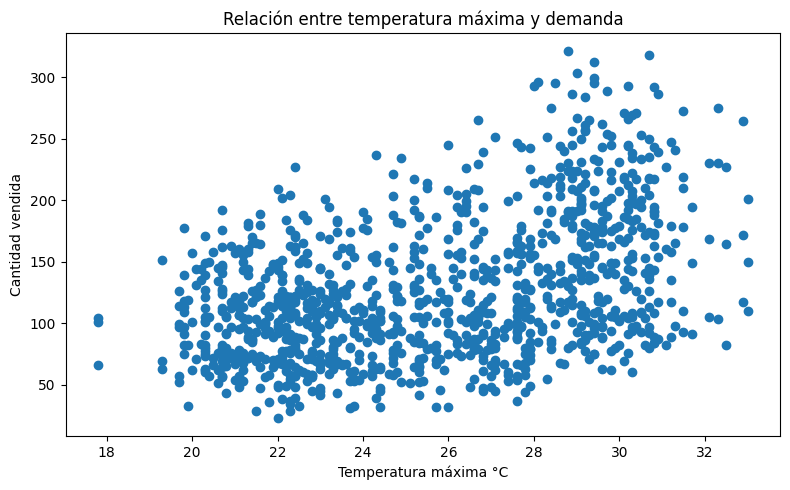

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(df["temperatura_maxima_celsius"], df["cantidad_vendida_total"])
plt.title("Relación entre temperatura máxima y demanda")
plt.xlabel("Temperatura máxima °C")
plt.ylabel("Cantidad vendida")
plt.tight_layout()
plt.show()

## Relación entre clima y demanda

Se revisa la relación entre temperatura y cantidad vendida. En el negocio de agua embotellada, se espera que temperaturas más altas puedan incrementar la demanda, especialmente en periodos de verano o días de calor extremo.

In [31]:
corr_ads = (
    df.groupby("id_sku")
    .apply(lambda x: pd.Series({
        "corr_ads": x["cantidad_vendida_total"].corr(x["inversion_ads_total"]),
        "corr_ads_lag1": x["cantidad_vendida_total"].corr(x["ads_lag1"]),
        "corr_ads_lag3": x["cantidad_vendida_total"].corr(x["ads_lag3"])
    }))
    .reset_index()
)

corr_ads

,id_sku,corr_ads,corr_ads_lag1,corr_ads_lag3
0,SKU_1L,0.270550,0.248672,0.230895
1,SKU_20L,0.299426,0.250264,0.262547
2,SKU_500ML,0.279855,0.261166,0.219380


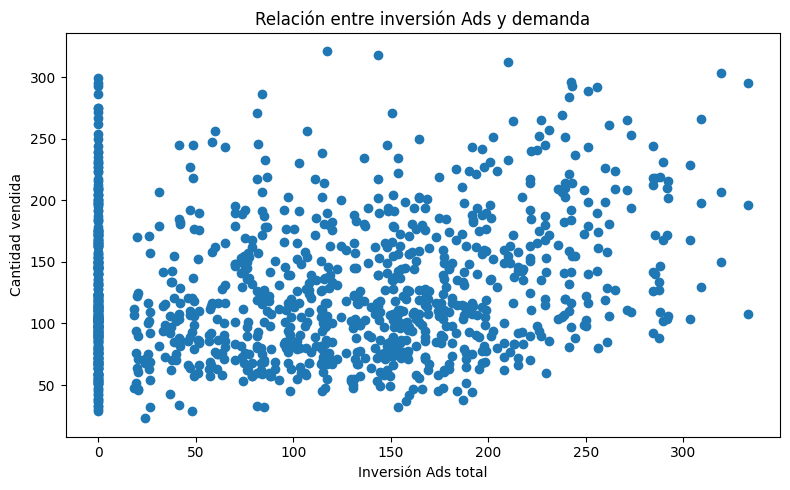

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(df["inversion_ads_total"], df["cantidad_vendida_total"])
plt.title("Relación entre inversión Ads y demanda")
plt.xlabel("Inversión Ads total")
plt.ylabel("Cantidad vendida")
plt.tight_layout()
plt.show()

## Relación entre marketing digital y demanda

Se analiza si la inversión publicitaria diaria y sus rezagos tienen relación con la demanda. Esto permite evaluar si las campañas de Ads podrían anticipar o explicar picos de venta.

In [33]:
demanda_censurada = (
    df.groupby("id_sku", as_index=False)
    .agg(
        dias_posible_quiebre=("riesgo_demanda_censurada", "sum"),
        total_dias=("riesgo_demanda_censurada", "count")
    )
)

demanda_censurada["porcentaje_dias_quiebre"] = (
    demanda_censurada["dias_posible_quiebre"] / demanda_censurada["total_dias"] * 100
).round(2)

demanda_censurada

,id_sku,dias_posible_quiebre,total_dias,porcentaje_dias_quiebre
0,SKU_1L,0,366,0.0
1,SKU_20L,0,366,0.0
2,SKU_500ML,0,366,0.0


## Demanda censurada

La demanda censurada ocurre cuando las ventas observadas no reflejan la demanda real porque el producto no tuvo stock suficiente. Este análisis es crítico para modelos de inventario, ya que una venta baja puede deberse a falta de stock y no necesariamente a baja demanda.

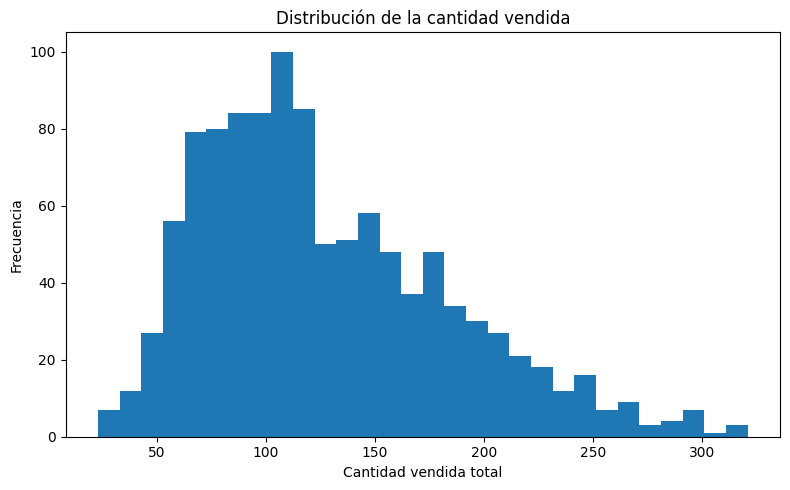

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(df["cantidad_vendida_total"], bins=30)
plt.title("Distribución de la cantidad vendida")
plt.xlabel("Cantidad vendida total")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

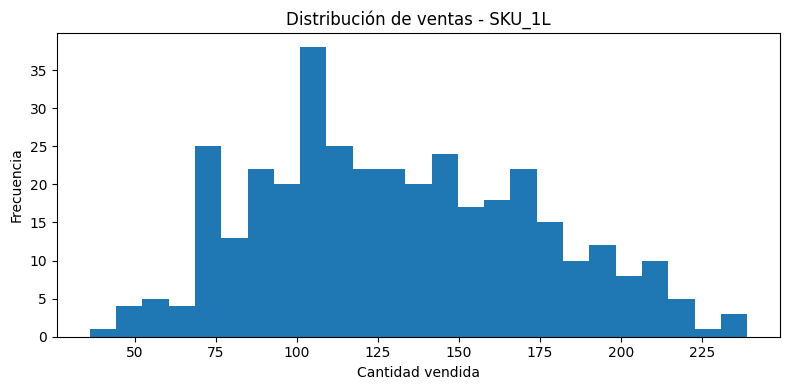

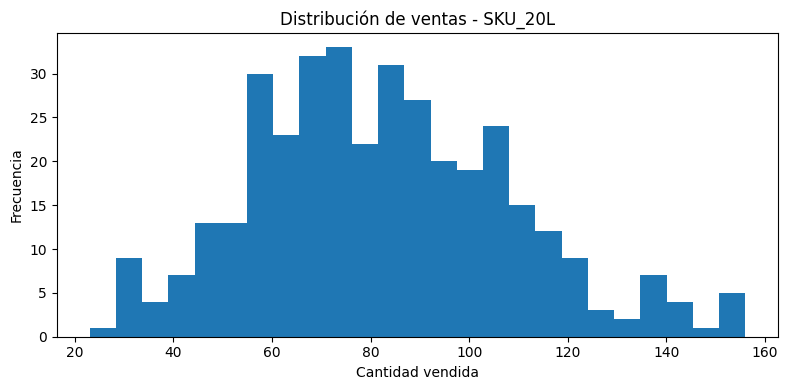

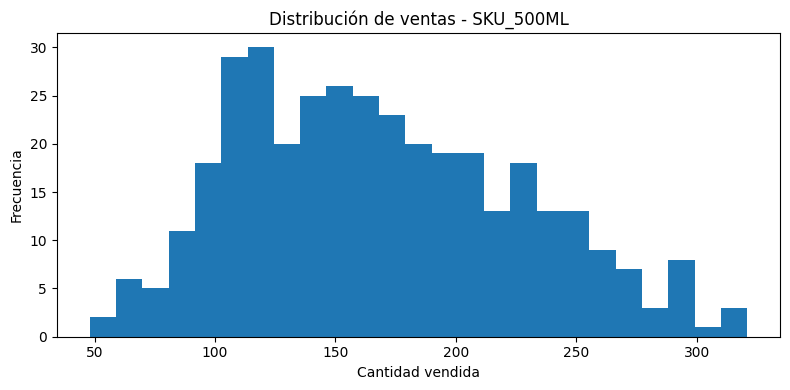

In [35]:
for sku in df["id_sku"].unique():
    temp = df[df["id_sku"] == sku]
    
    plt.figure(figsize=(8, 4))
    plt.hist(temp["cantidad_vendida_total"], bins=25)
    plt.title(f"Distribución de ventas - {sku}")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

## Distribución de la variable objetivo

La distribución de la cantidad vendida permite identificar concentración en ciertos rangos, valores extremos o diferencias importantes entre productos. Este análisis ayuda a definir si se requiere tratamiento adicional antes del entrenamiento.

In [36]:
columnas_corr = [
    "cantidad_vendida_total",
    "stock_apertura",
    "precio_unitario_promedio",
    "descuento_total",
    "inversion_ads_total",
    "clics_total",
    "temperatura_promedio_celsius",
    "temperatura_maxima_celsius",
    "humedad_porcentaje",
    "ventas_lag1",
    "ventas_lag7",
    "ventas_roll7",
    "ads_lag1",
    "ads_lag3"
]

corr = df[columnas_corr].corr(numeric_only=True)

corr

,cantidad_vendida_total,stock_apertura,precio_unitario_promedio,descuento_total,inversion_ads_total,clics_total,temperatura_promedio_celsius,temperatura_maxima_celsius,humedad_porcentaje,ventas_lag1,ventas_lag7,ventas_roll7,ads_lag1,ads_lag3
cantidad_vendida_total,1.000000,0.320528,-0.593506,0.027321,0.209511,0.180058,0.438068,0.433055,-0.282314,0.807436,0.765522,0.905051,0.190064,0.173247
stock_apertura,0.320528,1.000000,-0.516589,-0.085163,0.044153,0.035527,-0.065348,-0.065262,0.007877,0.325320,0.314530,0.360860,0.024225,0.050604
precio_unitario_promedio,-0.593506,-0.516589,1.000000,0.097358,-0.000983,0.000931,0.007134,0.006216,-0.002505,-0.588213,-0.557303,-0.652009,-0.002598,-0.005544
descuento_total,0.027321,-0.085163,0.097358,1.000000,0.080742,0.043668,-0.088241,-0.072166,0.014643,-0.005515,-0.061414,-0.024881,0.093904,0.149978
inversion_ads_total,0.209511,0.044153,-0.000983,0.080742,1.000000,0.974507,0.148394,0.136465,-0.100211,0.200489,0.090785,0.178598,0.721314,0.528677
clics_total,0.180058,0.035527,0.000931,0.043668,0.974507,1.000000,0.124820,0.110171,-0.078808,0.181463,0.077186,0.156326,0.699486,0.518666
temperatura_promedio_celsius,0.438068,-0.065348,0.007134,-0.088241,0.148394,0.124820,1.000000,0.977706,-0.623122,0.417995,0.452493,0.479841,0.130580,0.144272
temperatura_maxima_celsius,0.433055,-0.065262,0.006216,-0.072166,0.136465,0.110171,0.977706,1.000000,-0.605273,0.419655,0.445058,0.474832,0.124489,0.136452
humedad_porcentaje,-0.282314,0.007877,-0.002505,0.014643,-0.100211,-0.078808,-0.623122,-0.605273,1.000000,-0.244497,-0.284916,-0.301117,-0.061679,-0.126663
ventas_lag1,0.807436,0.325320,-0.588213,-0.005515,0.200489,0.181463,0.417995,0.419655,-0.244497,1.000000,0.756166,0.903427,0.215485,0.191653


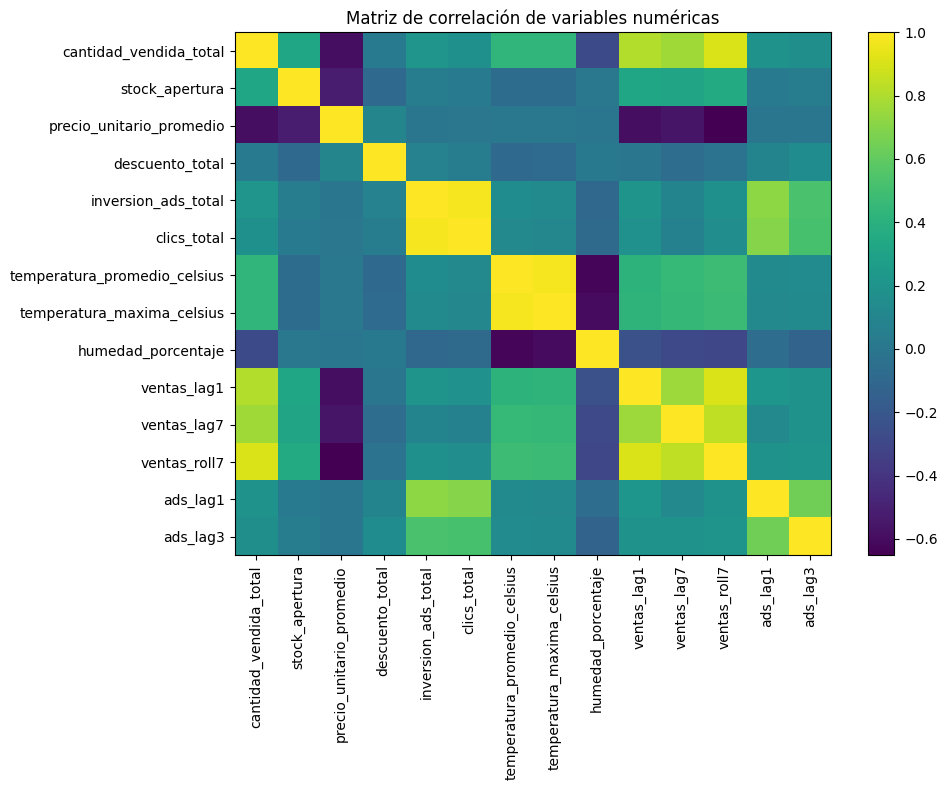

In [37]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

# Conclusiones del EDA

1. El dataset Gold presenta una granularidad adecuada para el modelo: una fila por fecha y SKU.

2. La variable objetivo `cantidad_vendida_total` se encuentra disponible para el entrenamiento del modelo.

3. Las variables de inventario, especialmente `stock_apertura`, son relevantes porque permiten evaluar disponibilidad antes de la venta y evitar fuga de datos con stock de cierre.

4. Las variables climáticas permiten capturar efectos externos asociados a la demanda de agua embotellada.

5. Las variables de marketing digital permiten analizar el posible impacto de campañas e inversión publicitaria en la demanda.

6. Los rezagos de ventas (`ventas_lag1`, `ventas_lag7`) y el promedio móvil (`ventas_roll7`) aportan información histórica importante para la predicción.

7. Se identificó la variable `riesgo_demanda_censurada`, que permite advertir casos donde las ventas observadas podrían no representar la demanda real por falta de stock.

8. Luego de esta validación exploratoria, el dataset se considera apto para pasar a la fase de entrenamiento del modelo predictivo.